In [ ]:
#aggregated analysis from all 3 stages
#uses data from other 3 files
#looks at raw export data (value) and usd/ton 

#comparable to aggregated regional analysis in terms of graph-type

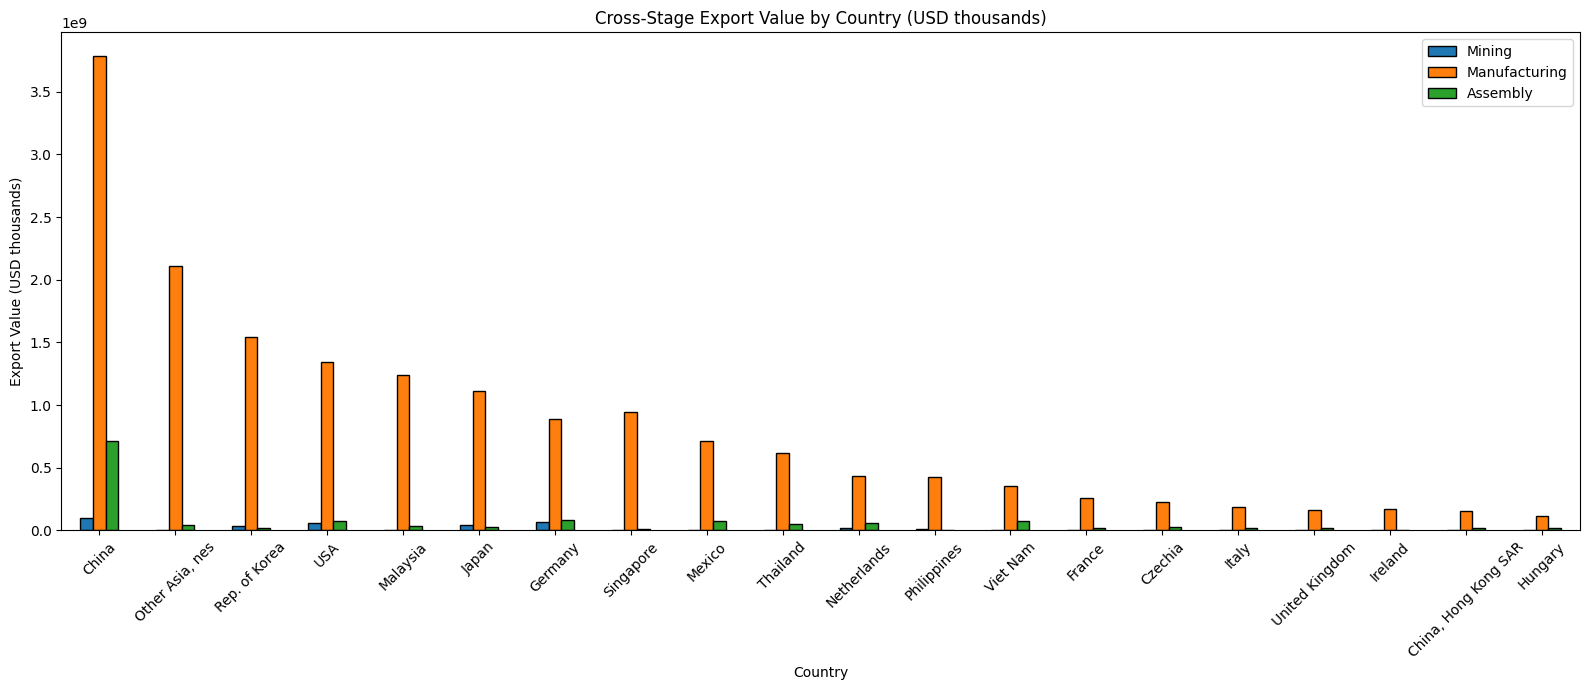

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

#  Load Export Value Data 
mining_val = pd.read_csv("../data/aggregated/mining_export_value.csv", index_col=0)
manufacturing_val = pd.read_csv("../data/aggregated/manufacturing_export_value.csv", index_col=0)
assembly_val = pd.read_csv("../data/aggregated/assembly_export_value.csv", index_col=0)

#  Compute total export value per country 
mining_total = mining_val.sum(axis=1)
manufacturing_total = manufacturing_val.sum(axis=1)
assembly_total = assembly_val.sum(axis=1)

#  Union of all countries from all stages 
all_countries = mining_total.index.union(manufacturing_total.index).union(assembly_total.index)

#  Build comparison DataFrame 
value_comparison = pd.DataFrame(index=all_countries)
value_comparison["Mining"] = mining_total.reindex(all_countries).fillna(0)
value_comparison["Manufacturing"] = manufacturing_total.reindex(all_countries).fillna(0)
value_comparison["Assembly"] = assembly_total.reindex(all_countries).fillna(0)

#  Filter top 20 countries by total export value 
top_countries = value_comparison.sum(axis=1).nlargest(20).index
value_comparison_top = value_comparison.loc[top_countries]

#  Plot 
ax = value_comparison_top.plot(kind="bar", figsize=(16, 7), edgecolor="black")
ax.set_title("Cross-Stage Export Value by Country (USD thousands)")
ax.set_ylabel("Export Value (USD thousands)")
ax.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


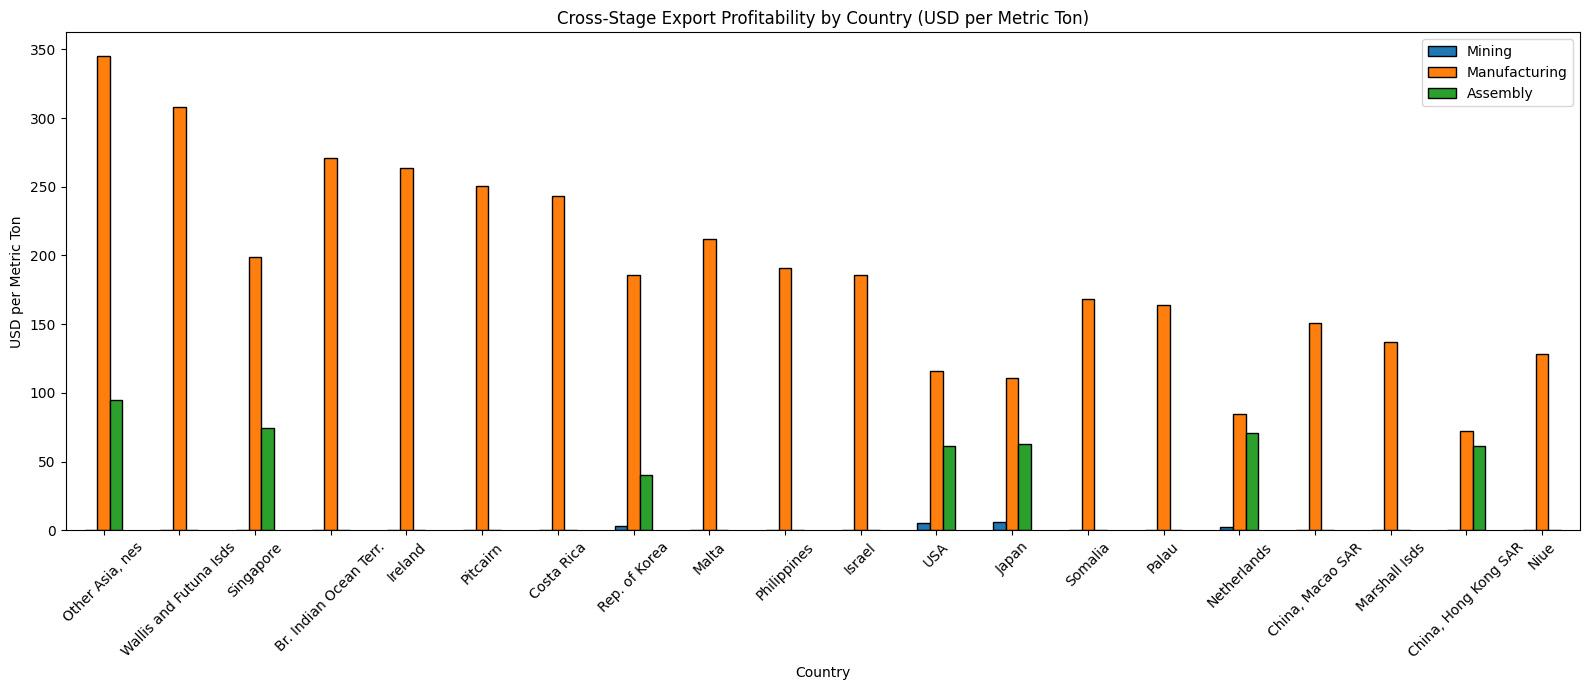

In [3]:
#  Load Quantity Data 
mining_qty = pd.read_csv("../data/aggregated/mining_export_quantity.csv", index_col=0)
manufacturing_qty = pd.read_csv("../data/aggregated/manufacturing_export_quantity.csv", index_col=0)
assembly_qty = pd.read_csv("../data/aggregated/assembly_export_quantity.csv", index_col=0)

mining_qty.replace(0, float('nan'), inplace=True)
manufacturing_qty.replace(0, float('nan'), inplace=True)
assembly_qty.replace(0, float('nan'), inplace=True)

#  USD per ton calculation 
mining_usd_per_ton = mining_val.sum(axis=1) / mining_qty.sum(axis=1)
manufacturing_usd_per_ton = manufacturing_val.sum(axis=1) / manufacturing_qty.sum(axis=1)
assembly_usd_per_ton = assembly_val.sum(axis=1) / assembly_qty.sum(axis=1)

#  Combine into one DataFrame 
profitability_df = pd.DataFrame({
    "Mining": mining_usd_per_ton,
    "Manufacturing": manufacturing_usd_per_ton,
    "Assembly": assembly_usd_per_ton
})

#  Filter top 20 by any nonzero profitability 
top_profit_countries = profitability_df.fillna(0).sum(axis=1).nlargest(20).index
profitability_top = profitability_df.loc[top_profit_countries].fillna(0)

#  Plot 
ax = profitability_top.plot(kind="bar", figsize=(16, 7), edgecolor="black")
ax.set_title("Cross-Stage Export Profitability by Country (USD per Metric Ton)")
ax.set_ylabel("USD per Metric Ton")
ax.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


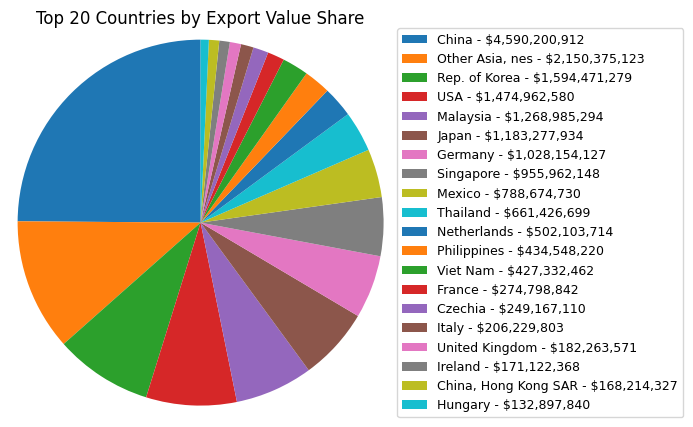

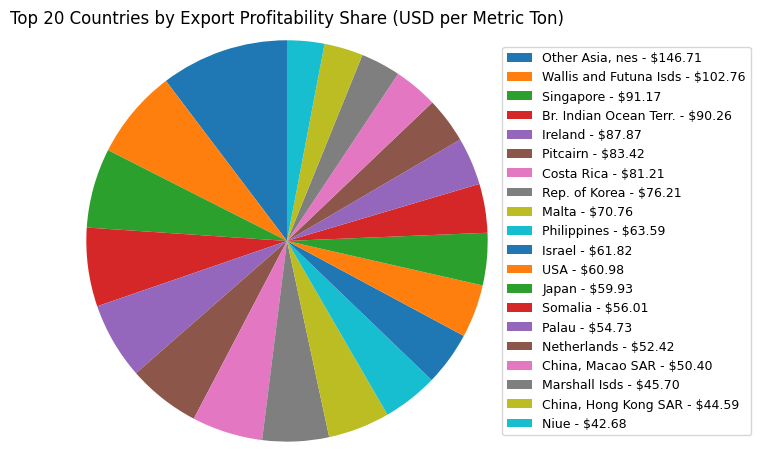

In [8]:
#total exports
patches, texts = plt.pie(values, startangle=90, radius=1.2)

# Create formatted legend labels
labels = [f"{c} - ${v:,.0f}" for c, v in zip(countries, values)]

# Sort patches and labels by value (descending)
patches, labels, _ = zip(*sorted(zip(patches, labels, values),
                                 key=lambda x: x[2], reverse=True))

#  Plot legend separately on the right 
plt.legend(patches, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.title("Top 20 Countries by Export Value Share")
plt.tight_layout()
plt.savefig("top_20_export_value_share.png", bbox_inches='tight')
plt.show()

#  Filter top 20 by any nonzero profitability 
top_profit_countries = profitability_df.fillna(0).sum(axis=1).nlargest(20).index
profitability_top = profitability_df.loc[top_profit_countries].fillna(0)

#  Calculate total profitability by country 
total_profitability_per_country = profitability_top.mean(axis=1)

#  Prepare Pie Chart Data for Profitability 
profit_countries = total_profitability_per_country.index.to_numpy()
profit_values = total_profitability_per_country.to_numpy()

#  Pie chart for total export profitability share by country 
patches, texts = plt.pie(profit_values, startangle=90, radius=1.2)

# Create formatted legend labels for profitability
profit_labels = [f"{p} - ${pp:,.2f}" for p, pp in zip(profit_countries, profit_values)]

# Sort patches and labels by value (descending)
patches, profit_labels, _ = zip(*sorted(zip(patches, profit_labels, profit_values),
                                        key=lambda x: x[2], reverse=True))

#  Plot legend separately on the right 
plt.legend(patches, profit_labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.title("Top 20 Countries by Export Profitability Share (USD per Metric Ton)")
plt.tight_layout()
plt.savefig("top_20_export_profitability_share.png", bbox_inches='tight')
plt.show()
